# Identification
Please indicate your name and parcours (e.g.: IMA, DIGIT, BIM, DAC, ..., Erasmus)

Student 1: Daria Shtyka M1 MIND

Student 2: 

# Practical work 1: introduction and image enhancement 

- Quick start for Python (10 minutes!) : https://www.stavros.io/tutorials/python/
- Quick start for Numpy : https://numpy.org/devdocs/user/quickstart.html#
- For Matlab users: Numpy is very similar but with some important difference, see http://mathesaurus.sourceforge.net/matlab-numpy.html.
- Keep in mind that in Python, exception of variable of scalar type, all is reference and affectation is not a copy. 


## Short introduction to image processing with Python

Help: use the function `help()` to get information on a Python objet. 

Images are stored as arrays that is the default type of the `numpy` module. Defaut type of array elements is `float64` according to the IEEE754 norm. Special float values are defined: infinity (`inf`) and undefined (`nan`, *not a number*), and some numerical constants, such as $\pi$.
 


In [25]:
# import numpy
import numpy as np

# predefined constants
print(np.inf,np.nan,np.pi)

# some values
print( 1., 1e10, -1.2e-3)


inf nan 3.141592653589793
1.0 10000000000.0 -0.0012


### Creating an array: several ways.

1. From a list of values (formally any Python iterable object). Elements of an array have the same **type**, determined by Numpy:

In [26]:
V = np.array([1,2,3])
M = np.array([[1,2,3],[4,5,6.]])
print ("V is of type",V.dtype)
print ("M is of type",M.dtype)

V is of type int64
M is of type float64


2. Without values: Numpy has constructors such as `empty()`, `zeros()`, `ones()`... Shape should be given (see below). Important: `empty()` does not initialize array elements.

In [27]:
I = np.zeros((3,4))
print(I)
J = np.empty((4,3))
print(J)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


3. From a sequence, prefer `arange()` from numpy to `range()` from python.

In [28]:
print(np.arange(10))
print(np.arange(0,10,2))
print(np.arange(9,-1,-.5))

[0 1 2 3 4 5 6 7 8 9]
[0 2 4 6 8]
[ 9.   8.5  8.   7.5  7.   6.5  6.   5.5  5.   4.5  4.   3.5  3.   2.5
  2.   1.5  1.   0.5  0.  -0.5]


### Shape of an array

Shape decribes the number of elements for each dimension. A vector is of dimension 1, a matrix is of dimension 2. Superior dimensions are possible. Shape is not size that is the number of elements of an array. Type of shape is always a tuple of integers. With previous example: 

In [29]:
print(I.shape, I.size)
print(J.shape, J.size)
print(V.shape, V.size)

(3, 4) 12
(4, 3) 12
(3,) 3


An important function/method is `reshape()` to change the shape of an array. Typical usage of `reshape()` is to transform a vector into a matrix or reciprocally. 

In [30]:
K = np.arange(12).reshape((3,4))
print("K 12 reshape (3, 4)", K)
print("K (3, 4) reshape(K,12)", np.reshape(K,(12)))
print("K is :", K)
print("K reshape(2, 2, 3)", K.reshape((2,2,3))) #last one is column always

K 12 reshape (3, 4) [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
K (3, 4) reshape(K,12) [ 0  1  2  3  4  5  6  7  8  9 10 11]
K is : [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
K reshape(2, 2, 3) [[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### Elements of an array

Access element by indices: two syntaxe are possible, the first given in the example is prefered. Negative index is possible with the same meanning of Python list.

In [31]:
I = np.arange(12).reshape((3,4))
print(I)
print(I[1,2])
print(I[0][0])
print(I[-1,0])

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
6
0
8


Access by group of indices using the operator `:` allows to extract subarray. General syntaxe is `start:end:step` and it is very powerfull:

In [32]:
print('extract the first line')
print(I[0,:])
print(I[0,0:])
print(I[0,::])
print(I[0,::1])
# help(np.ndarray)
print('extract center of the array')
print(I[1:3,1:3])

print('extract elements with even indices')
print(I[::2,::2])

print('print the horizontal mirror of an array')
print(I[:,::-1])


extract the first line
[0 1 2 3]
[0 1 2 3]
[0 1 2 3]
[0 1 2 3]
extract center of the array
[[ 5  6]
 [ 9 10]]
extract elements with even indices
[[ 0  2]
 [ 8 10]]
print the horizontal mirror of an array
[[ 3  2  1  0]
 [ 7  6  5  4]
 [11 10  9  8]]


### Array arithmetic

Operators and functions can be applied to arrays. Mostly, operations are element-wise (i.e. applied element by element). The consequence is arrays should have the same shape. One operand can also be scalar in most of time.

In [33]:
A = np.arange(12).reshape((3,4))
B = 2 * A + 1
C = A + B
D = np.cos(2*np.pi*A/12)
print(A)
print (D)
print (D**2)
print (D>0)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[ 1.00000000e+00  8.66025404e-01  5.00000000e-01  6.12323400e-17]
 [-5.00000000e-01 -8.66025404e-01 -1.00000000e+00 -8.66025404e-01]
 [-5.00000000e-01 -1.83697020e-16  5.00000000e-01  8.66025404e-01]]
[[1.00000000e+00 7.50000000e-01 2.50000000e-01 3.74939946e-33]
 [2.50000000e-01 7.50000000e-01 1.00000000e+00 7.50000000e-01]
 [2.50000000e-01 3.37445951e-32 2.50000000e-01 7.50000000e-01]]
[[ True  True  True  True]
 [False False False False]
 [False False  True  True]]


Array may be viewed as matrix, we can make some linear algebraic manipulation. For example, `np.matmul()` is the matrix multiplication. It can be used to build matrix from vector. An example, using the transpose operator `T`. 

In [34]:
L = np.arange(1,6).reshape((1,5))
# transpose of L. Warning: C remains a reference to L
C = L.T
# This could be better if your want to touch L 
C = L.T.copy()
print("L", L)
print("C transpose of L", C)

print("A 5*5 matrix:")
print(np.matmul(C,L))

print("A dot product, but result is a matrix:")
print(np.matmul(L,C))
print(np.matmul(L,C)[0,0])

print("dot() is prefered with vectors:")
V = np.arange(1,6)
print("V", V)
print("V.dot(V)",V.dot(V))
print("np.dot(V,V)", np.dot(V,V))

L [[1 2 3 4 5]]
C transpose of L [[1]
 [2]
 [3]
 [4]
 [5]]
A 5*5 matrix:
[[ 1  2  3  4  5]
 [ 2  4  6  8 10]
 [ 3  6  9 12 15]
 [ 4  8 12 16 20]
 [ 5 10 15 20 25]]
A dot product, but result is a matrix:
[[55]]
55
dot() is prefered with vectors:
V [1 2 3 4 5]
V.dot(V) 55
np.dot(V,V) 55


### Images

We make use of PIL module (https://pillow.readthedocs.io/en/stable/reference/Image.html) to load and write an image and easily converted to Numpy array. Be careful: array type depends on image.

In [35]:
from PIL import Image

# reading an image and convert to array
myimage = np.array(Image.open('img/moon.png'))

# write an image (alternative format) from an array
Image.fromarray(myimage).save('img/pout.jpg')

Array can be displayed as an image using Matplotlib module. Here a short example:

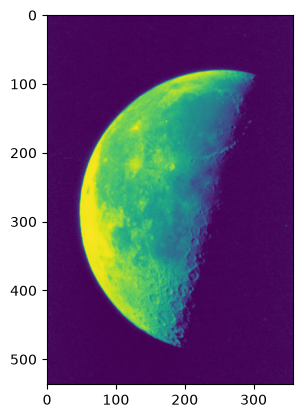

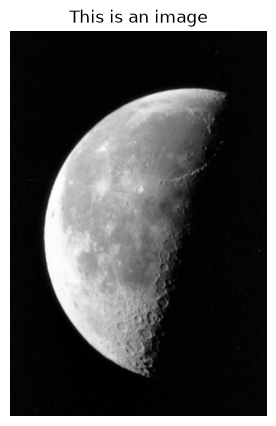

In [36]:
import matplotlib.pyplot as plt

# minimal example:
plt.imshow(myimage)
plt.show()

# with more controls:
w,h=400,400
plt.figure(figsize=(w/80,h/80))  # optional, to control the size of figure (unit: pixel)
plt.gray() # optional call to display image using a gray colormap
plt.title('This is an image') # optional: add a title
plt.axis('off') # optional: remove axes
plt.imshow(myimage)
plt.show()


See also:
- https://matplotlib.org/3.1.1/tutorials/introductory/images.html
- https://matplotlib.org/stable/gallery/images_contours_and_fields/image_demo.html

## Exercise 1
In this exercise, we work with image `img/moon.png`. If possible give two solutions: one with loops (for, while, ...) and one without loops using Numpy arithmetic avoiding ad-hoc Numpy functions such as `np.where()`. 

1. Write and test a function `openImage()` getting an image filename as argument and returning the array of pixel values.

In [37]:
from PIL import Image
import numpy as np

def openImage(fname):
    """ str -> Array 
    (notation above means the function gets a string argument and returns an Array object)
    """
    myimage = np.array(Image.open(fname))
    return myimage

openImage('img/moon.png')

array([[ 1,  3,  7, ...,  8, 16,  8],
       [ 3,  7,  3, ...,  4, 11, 12],
       [ 6,  4,  6, ...,  7,  2,  3],
       ...,
       [ 4,  8,  8, ...,  6,  4,  8],
       [ 4,  8,  8, ...,  4,  6,  6],
       [ 2,  3,  3, ...,  6,  9,  9]], shape=(537, 358), dtype=uint8)

2. Write and test a function `countPixels()` getting an array and an integer `k` as arguments and returning the number of pixels having the value `k`.

In [38]:
def countPixels(I,k):
    """ Array*int -> int"""
    cpt = 0
    for i in range(I.shape[0]):
        for j in range(I.shape[1]):
            if I[i][j] == k:
                cpt += 1
    return cpt

def countPixel1(I,k):
    cpt = 0
    return np.where(I==k)[0].size
# help(np.where)

print(countPixels(I, 5))
print(countPixel1(I,5))

1
1


3. Write and test a function `replacePixels()` getting an array and two intergers and replacing pixels having `k1`value to `k2` value and returning the new array. Be aware to not modify `I`.

In [201]:
def replacePixels(I,k1,k2):
    """ Array*int*int -> Array """
    new_array = np.copy(I)
    for i in range(I.shape[0]):
        for j in range(I.shape[1]):
            if I[i][j] == k1:
                new_array[i][j] = k2
    return new_array

print(I)
print(replacePixels(I,0,100))

[[107 108 107 ...  84  83  83]
 [109 106 108 ...  84  84  86]
 [107 106 110 ...  84  83  83]
 ...
 [ 97  99 101 ...  82  82  83]
 [ 99  98  98 ...  84  84  86]
 [101  99  99 ...  97  97  97]]
[[107 108 107 ...  84  83  83]
 [109 106 108 ...  84  84  86]
 [107 106 110 ...  84  83  83]
 ...
 [ 97  99 101 ...  82  82  83]
 [ 99  98  98 ...  84  84  86]
 [101  99  99 ...  97  97  97]]


4. Write and test a function `normalizeImage()` getting an array and two integers `k1` and `k2` and returning an array with elements normalized to the interval $[k_1,k_2]$. 

In [40]:
def normalizeImage(I,k1,k2):
    """ Array*int*int -> Array """
    new_array= np.copy(I)
    i1 = I.min()
    i2 = I.max()
    print(i1)
    print(i2)
    for i in range(I.shape[0]):
        for j in range(I.shape[1]):
            new_array[i][j] = ((I[i][j]-i1) / (i2-i1)) * (k2-k1) + k1
    return new_array
print(normalizeImage(I, 5, 7))
# print(I)


0
11
[[5 5 5 5]
 [5 5 6 6]
 [6 6 6 7]]


5. Write and test a function `inverteImage()` getting an array and returning and arry having inverted pixel values (i.e. the transform $k \mapsto 255-k$

In [41]:
def inverteImage(I):
    """ Array -> Array """
    new_array = np.copy(I)
    for i in range(I.shape[0]):
        for j in range(I.shape[1]):
            new_array[i][j] = 255 - new_array[i][j]
    return new_array
print(I)
print(inverteImage(I))

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[255 254 253 252]
 [251 250 249 248]
 [247 246 245 244]]


6. Write and test a function `computeHistogram()` getting an array and returning its histogram. Type of histogram can be an array or a list. It is forbidden to use an histogram method from a Python module. Is it possible to compute the histogram without explicitely visiting array pixels? 

In [89]:
def computeHistogram(I):
    """ Array -> list[int] """
    histogram = [0] * 256

    for i in range(I.shape[0]):
        for j in range(I.shape[1]):
            histogram[I[i][j]] += 1
    return histogram
print(computeHistogram(I))
#NO it's not possible because we must visit each pixel to count their occurrence
# use comments to answer to a verbal question

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


7. Write and test a function `thresholdImage()` getting an array `I` and an integer `s` and returning an array having elements set to 0 if corresponding element of `I` is lower than `s` or 255 otherwise.

In [43]:
def thresholdImage(I,s):
    """ Array*int -> Array """
    new_array = np.copy(I)
    for i in range(I.shape[0]):
        for j in range(I.shape[1]):
           if I[i][j] <=s:
                 new_array[i][j] = 0
           else:
            new_array[i][j] = 255
    return new_array
print(thresholdImage(I, 3))

[[  0   0   0   0]
 [255 255 255 255]
 [255 255 255 255]]


8. Using previous functions, give a series of instructions to read then to display an image, plot the histogram (one can use `plot()` or `bar()` from `matplotlib.pyplot` module), inverse the image and display it, plot its histogram.

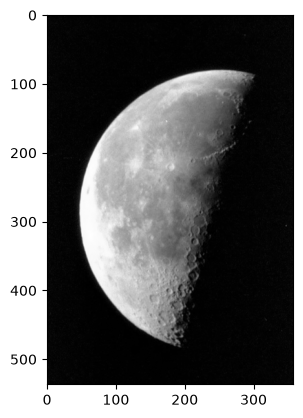

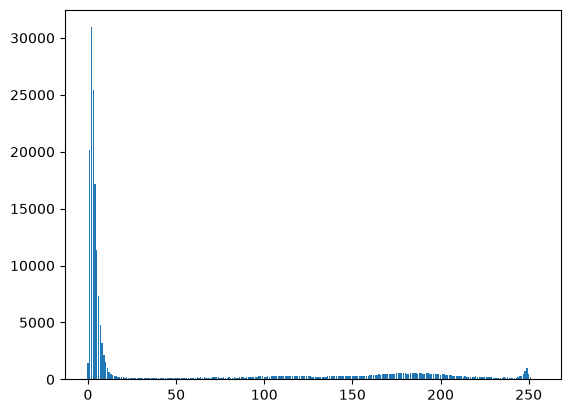

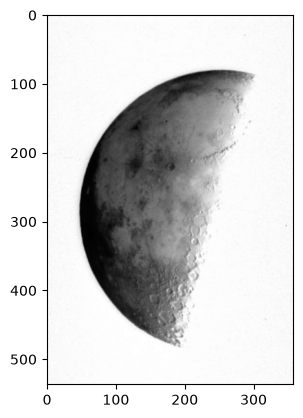

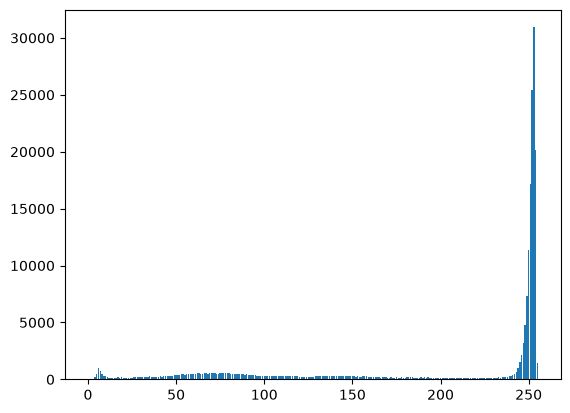

In [92]:
import matplotlib.pyplot as plt

## your code start below

# Read image
def read_image(fname):
    im_array = openImage(fname)
    plt.imshow(im_array)
    plt.show()
    #plt.hist(im_array, len(computeHistogram(im_array)))
    h = computeHistogram(im_array)
    plt.bar(range(len(h)), h)
    plt.show()

read_image('img/moon.png')

# Invert image
def invert_image(fname):
    im_array = openImage(fname)
    inverted_array = inverteImage(im_array)
    plt.imshow(inverted_array)
    plt.show()
    #plt.hist(inverted_array, len(computeHistogram(inverted_array)))
    h = computeHistogram(inverted_array)
    plt.bar(range(len(h)), h)
    plt.show()
invert_image('img/moon.png')

9. Give a series of instructions to read and display an image, plot the histogram, normalize the image to the interval $[10,50]$, compute the new histogram, display the image and the histogram. Remark: `imshow()` normalizes image. To avoid this and see the effect of the normalization, use `imshow()` with parameters `vmin=0,vmax=255`. Comment the results.

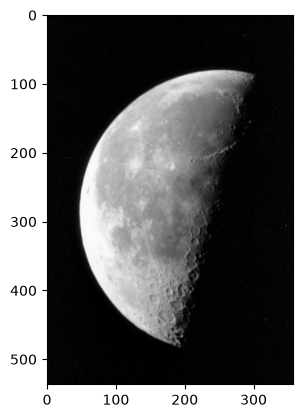

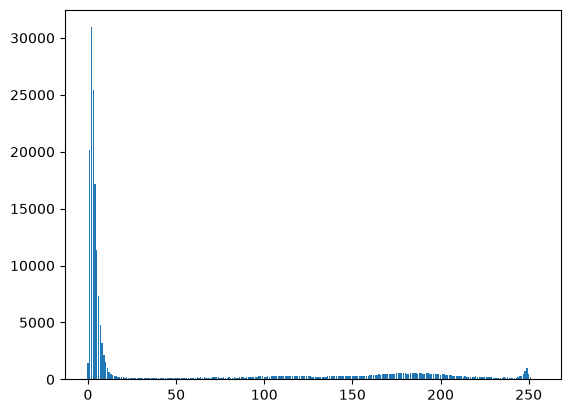

0
253


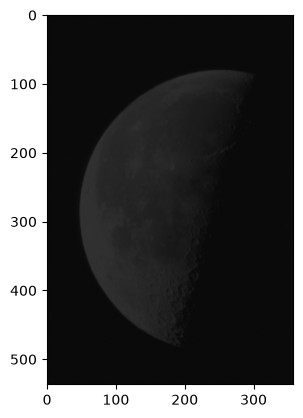

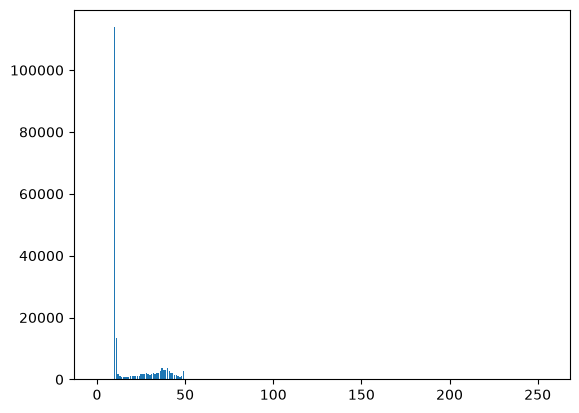

In [99]:

def normalisation_display(fname):
    #________ read and display an image ________
    I = openImage(fname)
    plt.imshow(I,vmin=0,vmax=255)
    plt.show()

    #________ plot the histogram ________
    h = computeHistogram(I)
    #print("h", h)
    #print("I", I)
    #----test pour voir aver plt.hist
    #print("hist")
    #plt.hist(I.reshape(I.size), bins=256, range=(0, 256))
    #plt.show()
    #----test pour voir aver plt.plot
    #print("plot")
    #plt.plot(h)
    #plt.show()
    #----test pour voir aver plt.bar
    #print("bar")
    plt.bar(range(len(h)), h) #(axe X y'en a 256 donc len de h, puis axe Y)
    plt.show()

    #________ normalize the image to the interval [10, 50] ________
    I_norm = normalizeImage(I, 10, 50)
    #________compute the new histogram________
    h_norm = computeHistogram(I_norm)
    #________display the image and the histogram________
    plt.imshow(I_norm,vmin=0,vmax=255)
    plt.show()
    plt.bar(range(len(h_norm)), h_norm)
    plt.show()
    

    #print("max", max(h))
normalisation_display('img/moon.png')
#help(plt.hist)
#Après la normalization de l'image on voit bien sur l'histogramme qu'on a des barres seulement
#entre 0 et 50 et les couleurs les plus claires de l'image sont devenu plus sombres car il ne doivent
#pas dépasse 50 photons après la normalisation.
#Les couleurs noirs sont restés pas touché puisque l'interavalle commence par 0 (couleur noir pas de photons)

10. Same question than 9. remplacing the normalization by a thresholding with parameter $s=127$.

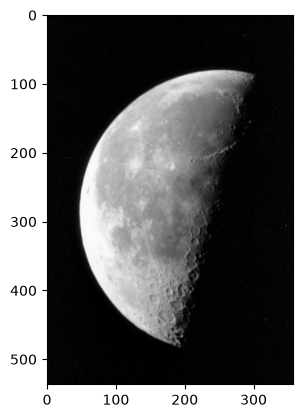

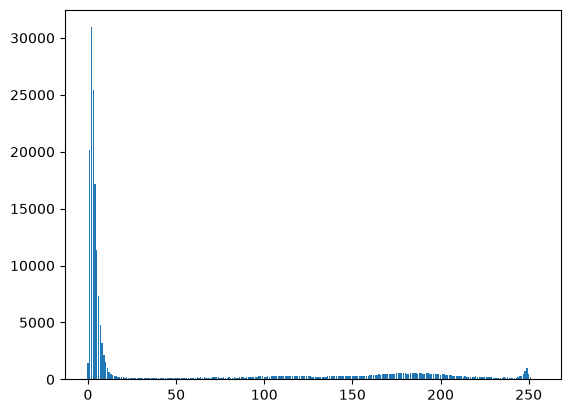

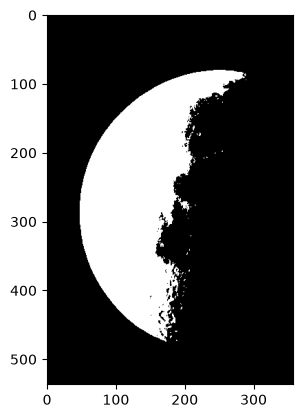

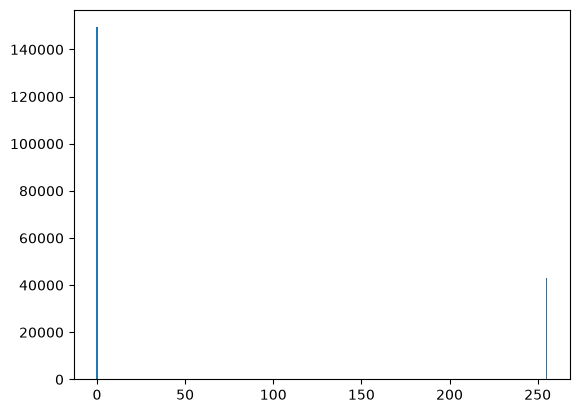

In [102]:
def threshold_display(fname):
    #________ read and display an image ________
    I = openImage(fname)
    plt.imshow(I,vmin=0,vmax=255)
    plt.show()

    #________ plot the histogram ________
    h = computeHistogram(I)
    plt.bar(range(len(h)), h) #(axe X y'en a 256 donc len de h, puis axe Y)
    plt.show()

    #________ normalize the image to the interval [10, 50] ________
    I_th = thresholdImage(I, 127)
    #________compute the new histogram________
    h_th = computeHistogram(I_th)
    #________display the image and the histogram________
    plt.imshow(I_th,vmin=0,vmax=255)
    plt.show()
    plt.bar(range(len(h_th)), h_th)
    plt.show()

threshold_display('img/moon.png')
#threshold_display('img/pout.png')
#Après thresholding on voit que les valeurs deviennet soit 0 soit 1 et sur l'histogramme il n'y a
#pas de barres à part sur 0 ou 255.
#L'image de départ de moon contient plus des valeurs sombres et moins de valeurs claires
#ce qu'on voit bien sur l'histogramme de thresholding après (la barre de 0 est plu haute de de 255)


## Exercise 2 - generate images

1. Create the array `I` 4 by 4 corresponding to the following image: <div> 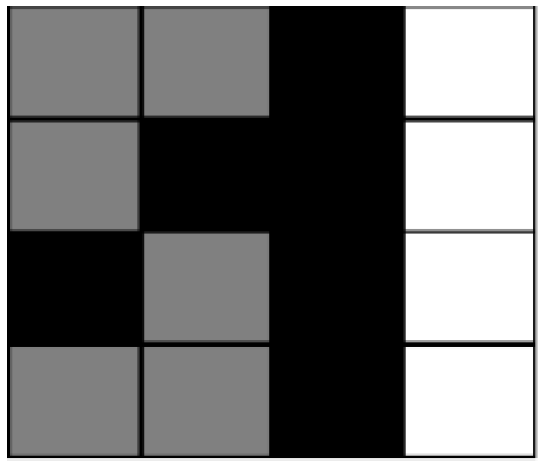 </div> Black pixels have value 0, white pixels value 255, and grey pixels value 127. Display the image using `imshow()` and plot the histogram.

[[127 127   0 255]
 [127   0   0 255]
 [  0 127   0 255]
 [127 127   0 255]]


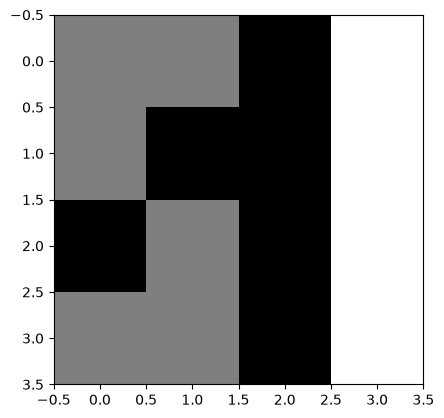

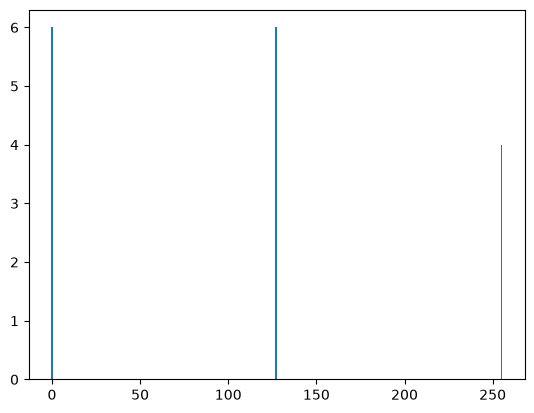

In [123]:
#I = [[127, 127, 0, 255],
#     [127, 0, 0, 255],
#     [0, 127, 0, 255],
#    [127, 127, 0, 255]
#    ]
I = np.zeros((4,4), dtype=int)
I[:, 2] = 0
I[:, 3] = 255
I[:, 0:2] = 127
I[1,1],I[2,0]  = 0, 0
print(I)
plt.imshow(I)
plt.show()
h = computeHistogram(I)
plt.bar(range(len(h)), h)
plt.show()

2. We want to generate an image having random values. Functions `rand()` and `randn()` from  `numpy.random` module generate an array of given shapes with random values following a uniform distribution on $[0,1[$ and a normal distribution respectively. Create an array of shape 512 by 512 having **integer** elements following a uniform distribution in the set $\{0,1,\cdots,255\}$. We also want to create an array following a Gaussian distribution with a mean of 128 and a standard deviation of 16 and with **integer** values.  Display the images and their histograms. Discuss the results.

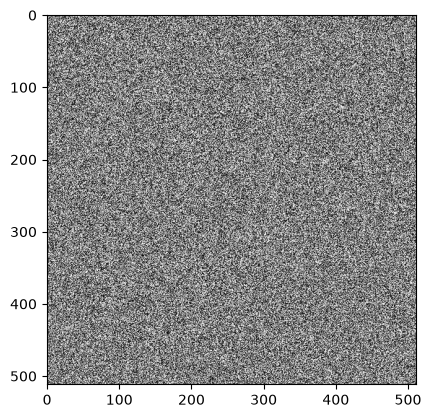

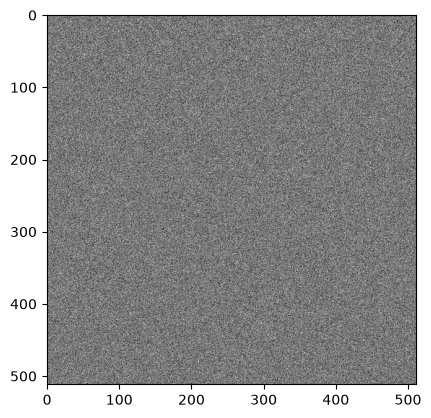

In [161]:
#help(np.random.rand)
#I = np.random.randint(0, 255, size = (512, 512))
#I = (np.random.rand(512, 512)*1000).astype(int)%256 #marche aussi mais le suivant est mieux
I = (np.random.rand(512, 512)*255).astype(int)
I_g = (16*np.random.randn(512, 512)).astype(int) + 128
plt.imshow(I)
plt.show()
plt.imshow(I_g)
plt.show()

#The results show that first image has more contrast while the second one is less contrasted which
#is due to a normal distribution

## Exercise 3: image manipulation
In this exercise, we work with image `img/pout.png`. 

1. Read and display this image

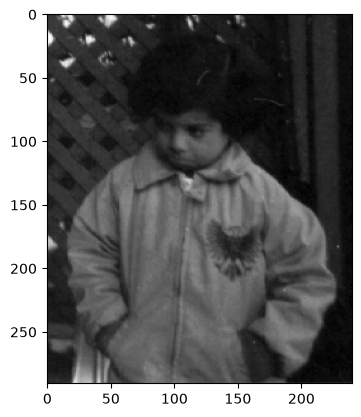

In [163]:
pout = openImage("img/pout.png")
plt.imshow(pout)
plt.show()

2. Examine the histogram. Determine the extrema of the image. What can you say about the quality of this image?

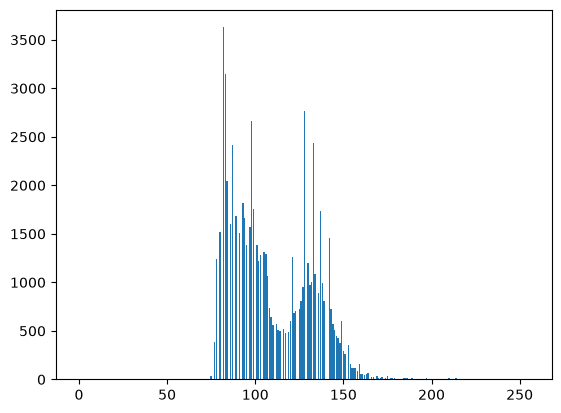

74
224


In [172]:
h_pout = computeHistogram(pout)
plt.bar(range(len(h_pout)), h_pout)
plt.show()
#extrema
print (pout.min())
print (pout.max())
#The contrast of the image is not high because the image uses only values from 74 to 255 of intensity levels

3. Using functions from Exercice 1, write the function `histogramEqualization()` getting one image, its histogram,  applying an histogram equalization and returning the new image. Test this function on `pout.png` and discuss the result.

h_cum [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 40, 40, 429, 1674, 1674, 3192, 3192, 6820, 9966, 12007, 12007, 13608, 16023, 16023, 17707, 17707, 19213, 19213, 21026, 22686, 24076, 24076, 25648, 28310, 30071, 30071, 31458, 32676, 33963, 33963, 35271, 36559, 37627, 38359, 38998, 39557, 39557, 40132, 40636, 41138, 41138, 41656, 42132, 42132, 42622, 43221, 44484, 45170, 45878, 45878, 46602, 47406, 48363, 51133, 51133, 52333, 53306, 54310, 56744, 57831, 57831, 58723, 60460, 61455, 62268, 62268, 62268, 63727, 64450, 65026, 65538, 65986, 66417, 66794, 67394, 67690, 67956, 67956, 68310, 68464, 68585, 68698, 68811, 68902, 69065, 69123, 69176, 69226, 69277, 69344, 69344, 69364, 69385, 69385, 69421, 69431, 69443, 69467, 69467, 69480, 69510, 69516, 69529, 69540, 69551, 69560, 69569, 69578, 69578, 69597, 69610, 69626

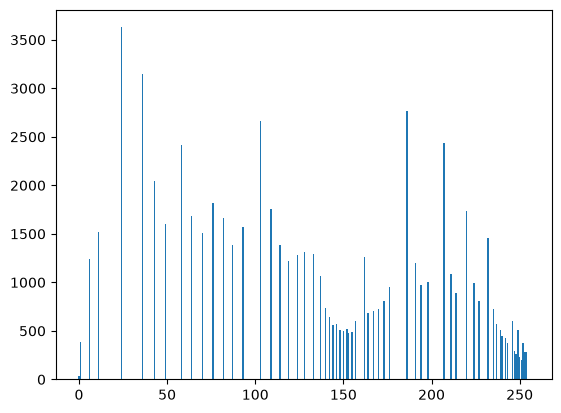

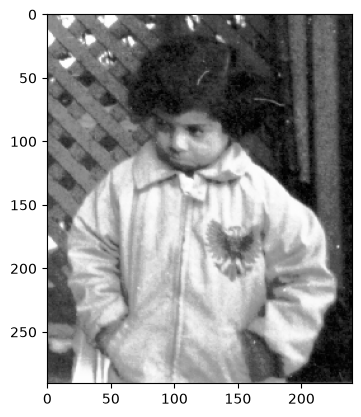

In [204]:
def histogramEqualization(I,h):
    """ Array * list[int] -> Array """
    #cumulative histogram
    h_cum = [h[0]]+[sum(h[:i]) + h[i] for i in range(1,len(h))]
    print("h_cum", h_cum)
    #dynamic range (le nb des niveaux d'intensité du gris)
    #L = I.max() - I.min()
    L = 256

    new_image = np.copy(I)
    print("len de h ", len(h))
    for i in range(len(h)):
        #ne marche pas avec cette fonction car on reparcours le nouveau image à chaque fois
        #et on peut modifier les pixels qu'on a déjà modifié et qu'on ne dois plus toucher
        #new_image = replacePixels(new_image,i, int( ((L-1)/(I.size)) * h_cum[i]))
        new_value = int(((L - 1) / I.size) * h_cum[i])
        
        for x in range(I.shape[0]):
            for y in range(I.shape[1]):
                if I[x][y] == i:
                    new_image[x][y] = new_value

    #int( (L-1/(I.size)) * h_cum[i]) for i in range(len(h_cum))]
    return new_image
eq_im = histogramEqualization(pout, computeHistogram(pout))
h_eq = computeHistogram(eq_im)
print("h_eq", h_eq)
plt.bar(range(len(h_eq)), h_eq)
plt.show()
plt.imshow(eq_im)
plt.show()

#Le resultat montre que sur l'histogramme on a maintenant en moyenne le nombre plus au moins égal
#des pixels des certains niveaux d'intensité et aussi qu'on a le nb plus équilibre de 0 à 255
#et non de 72 à 224 comme avant
